# Study 945 — The Hidden Financing — the teardown

The HAC regression that inverts the constant-leverage identity, the price-index trap, the block-bootstrap CI, the rolling pass-through through the rate cycle, the era and rate-regime cuts, the expense-ratio sweep, the costed break-even race against a self-financed margin replication, and the live synthetic control. Every real number is frozen from `docs/results.md` (Fingerprint `1c447f91bfae`).

> 💡 *In plain words:* a leveraged ETF is an index position plus a margin loan. This notebook works out the interest rate on the loan.

In [1]:
R = {'start': '2009-06-26', 'end': '2026-06-30', 'n_days': 4276, 'fp': '1c447f91bfae', 'irx_mean': 1.396, 'bil_realised': 1.267, 'sso_beta': 1.9972, 'sso_beta_t': -0.27, 'sso_r2': 0.99748, 'sso_alpha': -2.774, 'sso_alpha_se': 0.208, 'sso_alpha_t': -13.31, 'sso_drag': 2.962, 'sso_f': 2.072, 'sso_spread': 0.677, 'sso_allin': 2.962, 'sso_allin_spread': 1.567, 'upro_beta': 2.9894, 'upro_beta_t': -0.63, 'upro_r2': 0.99653, 'upro_alpha': -4.787, 'upro_alpha_se': 0.375, 'upro_alpha_t': -12.75, 'upro_drag': 5.07, 'upro_f': 2.08, 'upro_spread': 0.684, 'upro_allin': 2.535, 'upro_allin_spread': 1.139, 'boot_sso': 0.721, 'boot_sso_lo': 0.39, 'boot_sso_hi': 1.079, 'boot_upro': 0.768, 'boot_upro_lo': 0.432, 'boot_upro_hi': 1.114, 'gspc_sso_drag': -0.888, 'gspc_sso_f': -1.778, 'gspc_upro_drag': -0.694, 'gspc_upro_f': -0.802, 'roll_sso_mean': 0.545, 'roll_sso_sd': 0.437, 'roll_sso_slope': 1.058, 'roll_sso_int': 0.466, 'roll_sso_corr': 0.975, 'roll_upro_mean': 0.603, 'roll_upro_sd': 0.405, 'roll_upro_slope': 1.061, 'roll_upro_int': 0.52, 'roll_upro_corr': 0.979, 'sso_spread_se': 0.208, 'sso_spread_t': 3.25, 'sso_allin_t': 7.52, 'upro_spread_se': 0.188, 'upro_spread_t': 3.65, 'upro_allin_t': 6.07, 'irx_bey': 1.42, 'era_e_spread': 0.374, 'era_l_spread': 0.951, 'era_e_t': 1.74, 'era_l_t': 3.33, 'zirp_spread': 0.658, 'hiked_spread': 0.635, 'zirp_t': 2.69, 'hiked_t': 2.08, 'upro_era_e_spread': 0.38, 'upro_era_l_spread': 0.962, 'upro_era_e_t': 1.77, 'upro_era_l_t': 3.89, 'upro_zirp_spread': 0.631, 'upro_hiked_spread': 0.711, 'upro_zirp_t': 2.83, 'upro_hiked_t': 2.8, 'be_sso_early': 1.167, 'be_sso_late': 1.607, 'be_sso_zirp': 1.169, 'be_sso_hiked': 1.748, 'be_upro_early': 0.811, 'be_upro_late': 1.255, 'be_upro_zirp': 0.827, 'be_upro_hiked': 1.364, 'er_lo_spread': 0.817, 'er_hi_spread': 0.517, 'sharpe_spy': 0.836, 'sharpe_sso': 0.792, 'sharpe_upro': 0.792, 'race_sso_075': -0.64, 'race_sso_075_t': -4.56, 'race_sso_150': 0.11, 'race_sso_150_t': 0.78, 'race_sso_400': 2.61, 'race_sso_400_t': 18.59, 'race_sso_600': 4.61, 'race_sso_600_t': 32.84, 'race_upro_075': -0.57, 'race_upro_075_t': -2.25, 'race_upro_400': 5.93, 'race_upro_400_t': 23.36, 'race_upro_600': 9.93, 'race_upro_600_t': 39.12, 'be_sso_gross': 1.427, 'be_sso': 1.39, 'be_sso_5bp': 1.245, 'be_upro_gross': 1.09, 'be_upro': 1.035, 'be_upro_5bp': 0.817, 'turn_sso': 1.443, 'turn_upro': 4.33, 'turn_cost_sso': 0.04, 'turn_cost_upro': 0.11, 'syn_planted': 0.75, 'syn_2x': 0.683, 'syn_3x': 0.813, 'syn_err_2x': -0.067, 'syn_err_3x': 0.063}

## 1. The identity and its inversion

$$r_{fund,t} = \beta\, r_{bench,t} + \alpha + \varepsilon_t, \qquad \beta \to L, \quad \alpha \to -\frac{(L-1)f + ER}{252}$$

Two accounting details decide whether the answer is a rate or a nonsense:

1. **Basis.** The fund tracks the *index*; SPY runs `SPY_ER = 0.0945%`/yr below it, so the drag on an index basis is `−α·252 + β·SPY_ER`.
2. **Total return on both sides.** The wrappers distribute part of their collateral income; `auto_adjust=True` puts it back, so the measured drag is the *net* cost rather than an artefact of what was paid out.

One execution lag and only one, and it is not in this regression: the estimation half is a **measurement**, so fund and benchmark returns are contemporaneous by construction. The lag lives in the replication race in §7.

In [2]:
print('OLS, Newey-West SEs, drag on an index basis, %s -> %s (n=%d)'
      % (R['start'], R['end'], R['n_days']))
hdr = '{:<6} {:>8} {:>7} {:>10} {:>7} {:>8} {:>9} {:>9}'
print(hdr.format('fund', 'beta', 't vs L', 'alpha%/yr', 'se', 't',
                 'drag%/yr', 'f_impl%'))
for tag, k in (('SSO', 'sso'), ('UPRO', 'upro')):
    print(hdr.format(tag,
                     '{:.4f}'.format(R[k + '_beta']),
                     '{:+.2f}'.format(R[k + '_beta_t']),
                     '{:+.3f}'.format(R[k + '_alpha']),
                     '{:.3f}'.format(R[k + '_alpha_se']),
                     '{:+.2f}'.format(R[k + '_alpha_t']),
                     '{:.3f}'.format(R[k + '_drag']),
                     '{:.3f}'.format(R[k + '_f'])))
print()
print('mean ^IRX %.3f%%  ->  spread SSO %+.3f pp / UPRO %+.3f pp'
      % (R['irx_mean'], R['sso_spread'], R['upro_spread']))
print('all-in per borrowed dollar: SSO %.3f%% (^IRX %+.3f) / UPRO %.3f%% (^IRX %+.3f)'
      % (R['sso_allin'], R['sso_allin_spread'], R['upro_allin'],
         R['upro_allin_spread']))
print()
print('THE BAR — HAC t on the CLAIMS, not on the intercept:')
print('  spread over ^IRX  : SSO %+.2f / UPRO %+.2f   (leans on the assumed ER)'
      % (R['sso_spread_t'], R['upro_spread_t']))
print('  all-in over ^IRX  : SSO %+.2f / UPRO %+.2f   (no ER assumption at all)'
      % (R['sso_allin_t'], R['upro_allin_t']))
print('  the intercept t of %.2f only says the drag is non-zero, which the'
      % R['sso_alpha_t'])
print('  0.89% expense ratio guarantees before a cent of interest is charged.')

OLS, Newey-West SEs, drag on an index basis, 2009-06-26 -> 2026-06-30 (n=4276)
fund       beta  t vs L  alpha%/yr      se        t  drag%/yr   f_impl%
SSO      1.9972   -0.27     -2.774   0.208   -13.31     2.962     2.072
UPRO     2.9894   -0.63     -4.787   0.375   -12.75     5.070     2.080

mean ^IRX 1.396%  ->  spread SSO +0.677 pp / UPRO +0.684 pp
all-in per borrowed dollar: SSO 2.962% (^IRX +1.567) / UPRO 2.535% (^IRX +1.139)

THE BAR — HAC t on the CLAIMS, not on the intercept:
  spread over ^IRX  : SSO +3.25 / UPRO +3.65   (leans on the assumed ER)
  all-in over ^IRX  : SSO +7.52 / UPRO +6.07   (no ER assumption at all)
  the intercept t of -13.31 only says the drag is non-zero, which the
  0.89% expense ratio guarantees before a cent of interest is charged.


Realised betas of 1.9972 (*t* vs 2 = -0.27) and 2.9894 (*t* vs 3 = -0.63) — the wrappers do exactly what they say on the daily horizon, so the intercept is not soaking up a slope error. R² of 0.99748 / 0.99653.

**Which *t* carries the claim.** The intercept's -13.31 tests only that the drag is non-zero — guaranteed by a 0.89% expense ratio before any interest is charged — so it is not the inference bar and is never quoted as one. The claim is the **spread**: *t* = 3.25 / 3.65 (same intercept SE, rescaled by the *L*−1 borrowed dollars). The **all-in** spread, which carries no expense-ratio assumption, runs *t* = 7.52 / 6.07.

**What the residual contains.** Fee stripped, what remains is financing *plus* swap spreads, daily-reset slippage and residual tracking loss — inseparable in a return regression. **2.072% is an upper bound on the borrowing rate**, not the borrowing rate. The all-in cost per borrowed dollar needs no such caveat.

The cross-wrapper agreement (**2.072%** vs **2.080%**, 0.8 bp apart) is a genuine check — nothing in the estimator forces it — but not an independent one: both are ProShares funds on a shared swap desk. It rules out a mis-specified estimator; it does not confirm the level twice.

## 2. The price-index trap

"The S&P 500" as quoted (^GSPC) is a **price** index. Regress on it and the missing dividend yield, multiplied by *L*, swamps the drag:

| Benchmark | SSO drag | SSO implied *f* | UPRO drag | UPRO implied *f* |
|---|--:|--:|--:|--:|
| SPY **total return** (correct) | +2.962% | 2.072% | +5.070% | 2.080% |
| ^GSPC **price** index (wrong) | -0.888% | **-1.778%** | -0.694% | **-0.802%** |

A wrapper borrowing at −1.8% would be a money machine. It isn't; the benchmark was wrong. This is the single most common way published estimates of leveraged-ETF financing go wrong.

> 💡 *In plain words:* the index you see on television leaves dividends out. The fund doesn't. Compare like with like or the answer inverts.

## 3. Block-bootstrap CI on the spread

Resample the **slope-pinned** daily drag series `L·r_SPY − r_fund` in 21-day circular blocks (preserving tracking-error clustering) and push each draw through the same arithmetic. The pinned point sits ~4 bp above the free-slope one — precisely the disagreement you expect when β is 0.003 from *L*.

| Fund | Spread | 95% CI | share < 0 |
|---|--:|--:|--:|
| SSO | +0.721 pp | [+0.390, +1.079] | 0.0% |
| UPRO | +0.768 pp | [+0.432, +1.114] | 0.0% |

## 4. Rolling pass-through through the rate cycle

Rolling 252-day OLS, each estimate stamped on its window's last day (causal by construction), with the companion ^IRX figure the trailing mean over the identical window. Then regress the rolling implied *f* on the rolling ^IRX:

| Fund | spread mean | sd | pass-through slope | intercept | corr |
|---|--:|--:|--:|--:|--:|
| SSO | +0.545 | 0.437 | **1.058** | +0.466 | 0.975 |
| UPRO | +0.603 | 0.405 | **1.061** | +0.520 | 0.979 |

Slope ≈ 1 with a +0.5 pp intercept is the signature of a **pure pass-through with a constant mark-up**. Caveat stated plainly: overlapping 252-day windows leave these residuals massively autocorrelated, so the slope is *descriptive*; the inference bar is carried by the full-sample regression in §1.

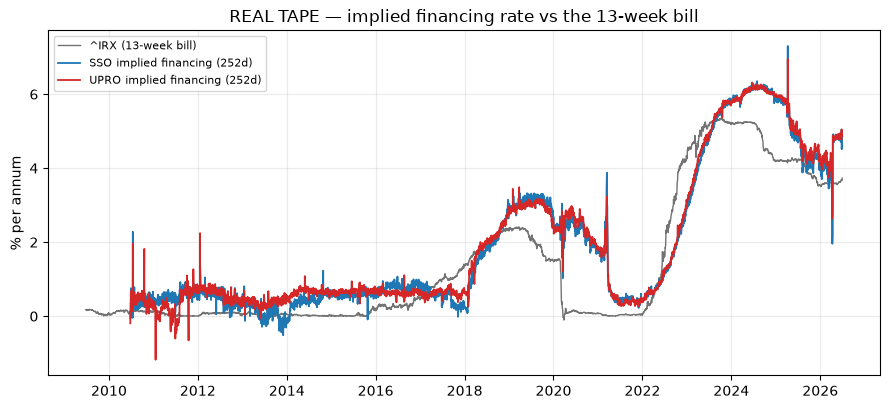

fingerprint 1c447f91bfae | as-of 2026-06-30


In [3]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath(os.path.join('..','..','..')))
%matplotlib inline
import matplotlib.pyplot as plt
from lev_financing import data, strategy as st

# REAL TAPE if the shared cache is present; otherwise say so and plot NOTHING.
# There is no synthetic fallback under this banner.
if not data.have_real():
    print('shared studies/_cache absent -> chart skipped '
          '(run lev_financing.data.fetch() once; no synthetic stand-in is drawn)')
else:
    px = data.load_prices().dropna()
    rets = px[['SSO', 'UPRO', 'SPY']].pct_change().dropna()
    rate = px['IRX'].reindex(rets.index)
    fig, ax = plt.subplots(figsize=(9, 4.2))
    ax.plot(rate.index, rate, lw=1.0, color='0.45', label='^IRX (13-week bill)')
    for fund, colour in (('SSO', '#1f77b4'), ('UPRO', '#d62728')):
        roll = st.rolling_financing(rets[fund], rets['SPY'], rate,
                                    data.FUNDS[fund], data.EXPENSE_RATIO[fund],
                                    bench_fee=data.SPY_EXPENSE_RATIO, window=252)
        ax.plot(roll.index, roll['implied_financing'], lw=1.3, color=colour,
                label='%s implied financing (252d)' % fund)
    ax.set_title('REAL TAPE — implied financing rate vs the 13-week bill')
    ax.set_ylabel('% per annum'); ax.legend(loc='upper left', fontsize=8)
    ax.grid(alpha=0.25)
    fig.tight_layout(); plt.show()
    print('fingerprint', data.fingerprint(px), '| as-of', data.AS_OF)

## 5. Two cuts — calendar era and rate regime

The 2018-01-01 split is the sample **midpoint** (2,142 days against 2,134), not a date anyone chose. Every *t* below is the **spread's** own HAC *t*.

| Cut | SSO spread (*t*) | UPRO spread (*t*) |
|---|--:|--:|
| 2009–2017 | +0.374 (**+1.74** ⚠) | +0.380 (**+1.77** ⚠) |
| 2018–2026 | **+0.951** (+3.33) | **+0.962** (+3.89) |
| ^IRX < 1% | **+0.658** (+2.69) | **+0.631** (+2.83) |
| ^IRX ≥ 1% | **+0.635** (+2.08) | **+0.711** (+2.80) |

The **rate-regime** cut is the one that passes cleanly: a 60 bp mark-up is most of the cost at the zero bound and a garnish at 5%, and both halves clear |*t*| = 2 at near-identical levels (0.658 vs 0.635 for SSO) — a structural charge, not a zero-bound artefact.

⚠ **The calendar cut is where this study is weakest, and it is not buried.** Pre-2018 the spread is +0.374 / +0.380 at *t* = 1.74 / 1.77 — **below the bar**: that half of the tape, alone, cannot reject "the wrappers borrowed at bills". After 2018 the mark-up roughly doubles (0.95 / 0.96, *t* = 3.33 / 3.89). Read it as: the **post-2018** level near +0.95 is what the tape establishes; the full-sample +0.68 is an average over a first half that is a weak estimate of a smaller number, and it is not a forward constant.

## 6. The one non-tape input, swept

The **drag is measured**; only its split between fee and financing depends on the prospectus expense ratio. A 10 bp error moves implied *f* by 10 bp/(*L*−1), so the 3x estimate is twice as robust to it. Across the whole ±15 bp band the spread runs from **+0.817** (ER 0.75%) to **+0.517** (ER 1.05%) for SSO — positive throughout. **There is no plausible expense ratio at which these wrappers borrow at T-bills.**

> 💡 *In plain words:* even if the published fee is wrong by a fifth, the conclusion doesn't move.

## 7. The race — wrapper vs self-financed daily-reset replication

The DIY arm holds *L*×SPY on margin at ^IRX + spread and resets to *L* every close, the same mechanic the fund runs. **One execution lag:** the position earning day *t*'s return was set at the close of *t−1*, and the rate charged over day *t* is the one quoted at the close of *t−1*. Reset turnover is *L*(*L*−1)|r| of NAV — 1.44%/day at 2x, 4.33%/day at 3x — charged one-way **against NAV** (0.04%/yr and 0.11%/yr at 1 bp, i.e. the reset is *not* the expensive part). Both arms excess-of-cash against BIL's realised total return. **No short leg anywhere, so no borrow fee** — the only borrowing is the long leverage being priced.

**Eligibility, not just price.** Reg T caps a US retail margin account's *initial* leverage at 2x, so the **3x DIY arm does not exist** in an ordinary account — it needs portfolio margin, futures or a prime broker. Every UPRO row below, and the +0.75% row at either leverage, is a *price* comparison rather than a choice a retail holder can make. No margin call is modelled either; the wrapper's loss is capped at NAV and the margin account's is not. Both omissions flatter the DIY arm, so the break-even is **conservative** for the wrapper.

**The *t* column is not evidence of an edge.** Both arms hold the same *L* × the same benchmark, so the difference is a near-deterministic cost gap plus tracking noise; its *t* grows mechanically with the assumed margin spread and with sample length. *t* = 39 means "the arithmetic is stable", not "39 sigma of alpha".

| Margin spread over ^IRX | SSO: fund − DIY (*t*) | UPRO: fund − DIY (*t*) |
|---|--:|--:|
| +0.75% | -0.64%/yr (-4.56) | -0.57%/yr (-2.25) |
| +1.50% | +0.11%/yr (+0.78) | — |
| +4.00% | **+2.61%/yr** (+18.59) | **+5.93%/yr** (+23.36) |
| +6.00% | **+4.61%/yr** (+32.84) | **+9.93%/yr** (+39.12) |

Excess Sharpes: SPY **0.836**, SSO 0.792, UPRO 0.792. Leverage is near Sharpe-neutral before costs; the ~0.045 both wrappers give up against SPY *is* the fee plus the financing.

**Break-even margin spread** — gross and net, and the answer that contains no broker assumption at all:

| One-way cost | SSO | UPRO |
|---|--:|--:|
| 0 bp (gross) | ^IRX +1.427% | ^IRX +1.090% |
| 1 bp (net, headline) | **^IRX +1.390%** | **^IRX +1.035%** |
| 5 bp | ^IRX +1.245% | ^IRX +0.817% |

**And it is an in-sample average that moves when you cut the sample** — quoted as a range, never as a constant (1 bp one-way):

| Cut | SSO | UPRO |
|---|--:|--:|
| 2009–2017 | ^IRX +1.167% | ^IRX +0.811% |
| 2018–2026 | ^IRX +1.607% | ^IRX +1.255% |
| ^IRX < 1% | ^IRX +1.169% | ^IRX +0.827% |
| ^IRX ≥ 1% | ^IRX +1.748% | ^IRX +1.364% |

The level swings by ±0.3 pp. What does not move is the decision at realistic retail rates: the break-even never exceeds ^IRX +1.75% in any cut, against retail margin at ^IRX + 4 to 6% — safe by a factor of three. The conclusion is robust; the third decimal is not.

## 8. Live synthetic control (offline — never supports the stamp)

Synthetic wrappers assembled from a *known* financing rate over 24 years with a planted 0.15% → 5.00% rate step and 5 bp/day tracking noise. Because the planted and null worlds share a seed — hence the same index path and the same noise — the *difference* between the two recovered spreads is the planted effect with zero residual sampling error, which is what the test-suite asserts as an equality.

In [4]:
import numpy as np
from lev_financing import data, strategy as st
print('SYNTHETIC (offline) — not the real tape\n')
for L in (2, 3):
    got = {}
    for ss in (1.0, 0.0):
        vals = [st.synthetic_detect(*data.synthetic_panel(signal_strength=ss, seed=945+s),
                                    leverage=L)['spread_over_rate_pct'] for s in range(6)]
        got[ss] = np.array(vals)
    print('%dx  planted 75 bp -> %+.3f pp (6-seed mean, sd %.3f)'
          % (L, got[1.0].mean(), got[1.0].std()))
    print('    null    0 bp -> %+.3f pp' % got[0.0].mean())
    print('    planted minus null = %+.4f pp (exactly the planted effect)\n'
          % (got[1.0] - got[0.0]).mean())
p1, t1 = data.synthetic_panel(signal_strength=1.0, seed=945)
roll = st.rolling_financing(p1['fund_3'].pct_change().dropna(),
                            p1['index'].pct_change().dropna(), p1['rate'], 3,
                            t1['expense_ratio_pct'], window=252)
print('rolling estimator on the planted rate step: %.2f%% -> %.2f%% (planted %.2f -> %.2f)'
      % (roll['implied_financing'].iloc[:200].mean(),
         roll['implied_financing'].iloc[-200:].mean(),
         t1['rate_low_pct'] + t1['planted_spread_pct'],
         t1['rate_high_pct'] + t1['planted_spread_pct']))

SYNTHETIC (offline) — not the real tape



2x  planted 75 bp -> +0.683 pp (6-seed mean, sd 0.197)
    null    0 bp -> -0.067 pp
    planted minus null = +0.7500 pp (exactly the planted effect)



3x  planted 75 bp -> +0.813 pp (6-seed mean, sd 0.061)
    null    0 bp -> +0.063 pp
    planted minus null = +0.7500 pp (exactly the planted effect)



rolling estimator on the planted rate step: 0.90% -> 5.89% (planted 0.90 -> 5.75)


## Verdict

- **Signal — Real.** Implied financing **2.072% / 2.080%** against ^IRX 1.396% — a **+0.68 pp** mark-up whose own HAC *t* is **3.25 / 3.65**, past the |*t*| ≥ 2 bar. (The intercept *t* of -13.31 tests only that the drag is non-zero — the fee alone guarantees that, so it is not the bar.) Bootstrap CI [+0.39, +1.08] clear of zero; both rate regimes clear |*t*| = 2; the whole ER sweep positive; the **all-in** spread, free of any fee assumption, at +1.57 / +1.14 pp (*t* = 7.52 / 6.07); pass-through slope 1.06.
- **What the badge does not cover.** (1) **Upper bound, not interest** — swap spreads, reset slippage and tracking loss are inside the same residual. (2) **The early era is weak** — pre-2018 the spread is +0.37 at *t* = 1.74, below the bar; the robust finding is the post-2018 +0.95. (3) **Survivorship** — SSO and UPRO survived a cohort that lost members and are both ProShares funds on a shared swap desk, so their agreement is a consistency check, not independent confirmation, and the estimate is a **floor** for the class.
- **Tradability — Investable.** A cost decision with a break-even you can compute from your own rate card: **^IRX + 1.39%** at 2x, **^IRX + 1.03%** at 3x, never above ^IRX + 1.75% in any cut. Above that line the wrapper wins by +2.6% to +9.9%/yr — safe by a factor of three against retail margin at bills + 4 to 6%, which is why the badge survives the wobble in the estimate. (Those races' *t* of 18-39 are mechanical, not evidence.) Below the line the margin account wins by -0.64%/yr — but a prime-broker tier, and the 3x DIY arm **Reg T does not permit in a retail margin account**, are not available to the holder this rule addresses.
- **Out of scope.** Only the financing is priced here. The daily reset also changes the *shape* of the payoff — variance drag, path dependence, the −60% and −77% drawdowns — and none of that is netted into these numbers.